#**Synapse Week Two**

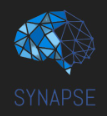



# Synapse Task 2B: SVM & Ensembles

Welcome to Task 2B! In Task 2A, we explored our "individual" baseline classifiers: Logistic Regression, Naive Bayes, and single Decision Trees. You saw firsthand how simple models behave, where their assumptions hold, and how unconstrained trees can run wild with variance.

Now, we level up. In this notebook, we cover **Support Vector Machines (SVM)**—an algorithm that reasons geometrically about margins and hyperplanes—and **Ensemble Methods**, a powerful family of techniques that combine many weak learners into one robust, high-performing model. This notebook closes our classification arc before a dedicated Research Task connecting ensemble techniques back to the Linear Regression you built in Task 1A.

Chalo, let's get building!

## Part 0 — Quick Recap & Rebuild

Before diving into new algorithms, we need our sanitized data ready. We'll reuse the exact same IBM Telco Customer Churn dataset, cleaning steps, and 70:30 train-test split from Task 2A so every comparison remains apples-to-apples.

No new teaching here—just reloading and setting the stage.

In [58]:
# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

In [59]:
# Import base libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [60]:
# Hint: Reload and clean exactly as in Task 2A — TotalCharges coercion, drop NaNs, drop customerID, encode Churn to 0/1, One-Hot encode nominal features, and perform a 70:30 stratified train-test split
df = pd.read_csv('./WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop(columns=['customerID'], inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Part 1 — Support Vector Machines & Kernels

While Logistic Regression searches for any decision boundary separating the classes, Support Vector Machines (SVM) search for the **maximum-margin hyperplane**—the line or plane that stays as far away from the closest training samples as mathematically possible. Those critical points hugging the margin edges are called **support vectors**.

The geometric margin width between the two boundary planes is given by:

$$\text{Margin} = \frac{2}{\|w\|}$$

Maximizing this margin is equivalent to minimizing $\frac{1}{2}\|w\|^2$. When classes cannot be separated with a straight cut in the current feature space, SVM deploys the **Kernel Trick**: it maps data points into a higher-dimensional space where a linear boundary *can* slice them apart cleanly, computing inner products without ever explicitly calculating the expensive coordinate transformations.

### Helpful Resources
- [StatQuest: Support Vector Machines Main Idea](https://www.youtube.com/watch?v=efR1C6CvhmE) *(Visual intuition of margins and soft margins)*
- [SVM Formulation & Boundary Intuition](https://www.youtube.com/watch?v=H9yACitf-KM) *(Short video on hyperplanes)*
- [Demystifying Support Vector Machines](https://towardsdatascience.com/demystifying-support-vector-machines-8453b39f7368/) *(Margin geometry and objective setups)*
- [StatQuest: Polynomial Kernel](https://youtu.be/Toet3EiSFcM) *(Watch how higher dimensions untangle points)*
- [StatQuest: The Radial Basis Function (RBF) Kernel](https://youtu.be/Qc5IyLW_hns) *(Visualizing infinite-dimensional projection)*
- [Kernel Feature Map Derivation](https://xavierbourretsicotte.github.io/Kernel_feature_map.html) *(Optional: rigorous inner-product substitution for curious math folks)*
- [Maths Behind SVM](https://www.youtube.com/watch?v=Js3GLb1xPhc) *(Supplementary video walk-through of the optimization setup)*

### Step 1.1: The Kernel Trick in Action (2D Concentric Circles)

To build visual intuition before tackling our high-dimensional churn data, let's create a synthetic 2D dataset using `make_circles`. A linear boundary cannot separate inner and outer rings—let's see what an RBF kernel does.

In [61]:
# Hint: Generate concentric circles using sklearn.datasets.make_circles
# from sklearn.datasets import make_circles
# X_circ, y_circ =
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=500, factor=0.4, noise=0.1, random_state=42)


In [62]:
# Hint: Fit SVC(kernel='linear') and SVC(kernel='rbf') on (X_circ, y_circ)
from sklearn.svm import SVC

svc_linear = SVC(kernel='linear').fit(X_circ, y_circ)
svc_rbf = SVC(kernel='rbf').fit(X_circ, y_circ)



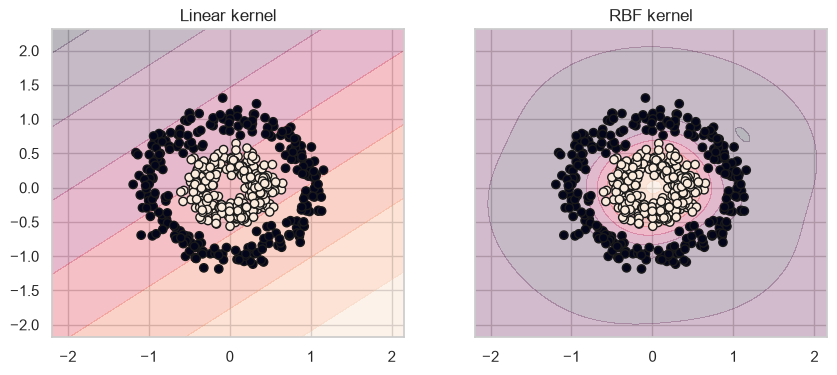

In [63]:
from sklearn.inspection import DecisionBoundaryDisplay
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, model, title in [(axes[0], svc_linear, 'Linear kernel'),
                         (axes[1], svc_rbf, 'RBF kernel')]:
    DecisionBoundaryDisplay.from_estimator(model, X_circ, ax=ax, alpha=0.3)
    ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, edgecolors='k')
    ax.set_title(title)

plt.show()

**Question:** Why does the linear kernel fail completely on this concentric dataset, and what does the RBF kernel do differently to carve out that circular boundary? Explain in plain English without formulas. 🤔  
**Answer:** 
Linear: only draws straight lines, so it can't separate rings (about 50% accuracy).

RBF: judges by closeness to other points, so it wraps a circle around the inner ring.

### Step 1.2: Feature Scaling for SVM on Telco Data

SVM measures geometric distances to determine margin widths. If one feature is measured in thousands (`TotalCharges`) and another spans 0 to 1, the wider-scale feature will dominate the distance calculations and distort the margin.

In [64]:
# Hint: Standardize continuous features ['tenure', 'MonthlyCharges', 'TotalCharges']
# from sklearn.preprocessing import StandardScaler
# scaler =
# Remember: fit_transform on X_train, transform on X_test!
# num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# X_train[num_cols] =
# X_test[num_cols] =
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [65]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc_linear = SVC(kernel='linear').fit(X_train, y_train)
svc_rbf = SVC(kernel='rbf').fit(X_train, y_train)

print('Linear:', accuracy_score(y_test, svc_linear.predict(X_test)))
print('RBF:   ', accuracy_score(y_test, svc_rbf.predict(X_test)))

Linear: 0.7981042654028436
RBF:    0.795260663507109


**Question:** Why was standardizing features crucial for SVM here, whereas Decision Trees and Naive Bayes in Task 2A did not care about feature scales at all? 🤔  
**Answer:**

### Step 1.3: Training Support Vector Classifiers on Telco Churn

Now let's apply `SVC` to our real churn dataset across three distinct kernels: `linear`, `rbf`, and `poly`.

In [66]:
# Hint: Loop through kernels ['linear', 'rbf', 'poly'], fit SVC(kernel=k, random_state=42) on X_train/y_train,
# and print the test accuracy for each
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

for k in ['linear', 'rbf', 'poly']:
    svc = SVC(kernel=k, random_state=42).fit(X_train, y_train)
    print(f"{k}: {accuracy_score(y_test, svc.predict(X_test)):.4f}")


linear: 0.7981
rbf: 0.7953
poly: 0.7919


**Question:** Can you name one real-world production use case outside churn prediction where Support Vector Machines are preferred over other classifiers? 🤔  
**Answer:** TF-IDF Text

## Part 2 — Why Combine Models? (Bias-Variance, Revisited)

In Task 2A, you plotted tree depth versus error and uncovered the fundamental tug-of-war in supervised learning: shallow trees suffer from high bias (underfitting), while deep unconstrained trees suffer from high variance (overfitting).

Ensemble learning offers a way to push past that trade-off by combining multiple models:
- **Bagging (Bootstrap Aggregating):** Trains multiple high-variance, deep models in parallel on random slices of the data, then averages their predictions. Averaging decorrelated predictions slashes variance without increasing bias.
- **Boosting:** Chains multiple high-bias, shallow models sequentially. Each new model focuses its learning capacity on the samples misclassified by preceding rounds, systematically reducing bias.

### Helpful Resources
- [Bagging vs. Boosting: Deep Dive for Tree-Based Models](https://medium.com/data-science-collective/bagging-vs-boosting-a-deep-dive-into-ensemble-learning-for-tree-based-models-b3a061da3e62) *(Ties ensemble strategies directly to Task 2A's bias-variance curves)*
- [How Gradient Boosting Actually Works Under the Hood](https://letsdatascience.com/blog/how-gradient-boosting-actually-works-under-the-hood-building-it-from-scratch-in-python) *(Step-by-step intuition)*

**Question:** In your own words, why does averaging the predictions of many overfit, high-variance decision trees tend to cancel out their individual overfitting? 🤔  
**Answer:**

## Part 3 — Bagging & Random Forest

A single decision tree is sensitive: small tweaks to the training data can yield an entirely different tree structure. **Bagging** stabilizes this by drawing bootstrap samples (random sampling with replacement), training an independent tree on each, and aggregating votes.

**Random Forest** adds a crucial enhancement: whenever a tree considers a split, it is restricted to a random subset of features (typically $\sqrt{p}$). This prevents a few dominant features from dictating every tree, ensuring the ensemble is populated by diverse, decorrelated learners.

### Helpful Resources
- [Ensemble Learning: Bagging Explained](https://www.youtube.com/watch?v=KIOeZ5cFZ50) *(Core bagging mechanics)*
- [StatQuest: Random Forests Part 1 - Building and Using](https://youtu.be/J4Wdy0Wc_xQ) *(The quintessential visual overview)*
- [The Secret Sauce Behind Random Forests](https://medium.com/@pacosun/the-secret-sauce-behind-random-forests-c5d77d850d3c) *(The intuitive weathermen-averaging analogy)*
- [RandomForestClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) *(API reference)*
- [Random Forest Implementation Walkthrough](https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s) *(Quick coding guide)*

### Step 3.1: Fitting a Random Forest Classifier

Let's train a `RandomForestClassifier` on our Telco churn training data.

In [67]:
# Hint: from sklearn.ensemble import RandomForestClassifier
# Fit RandomForestClassifier(n_estimators=100, random_state=42) on X_train, y_train
# rf =
# rf.fit(...)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report

rf=RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=1,
    class_weight='balanced'
)
rf.fit(X_train,y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [68]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# from sklearn.metrics import classification_report, accuracy_score
# y_pred_rf =
# print("Random Forest Accuracy:",...)
# print("\nClassification Report:\n",...)
pred_rf=rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.7701421800947867
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1549
           1       0.56      0.64      0.60       561

    accuracy                           0.77      2110
   macro avg       0.71      0.73      0.72      2110
weighted avg       0.78      0.77      0.77      2110



**Question:** What is the technical difference between a Random Forest and a single Decision Tree beyond just "it uses many trees"? Under what specific circumstances could a Random Forest produce the exact same predictions as a single Decision Tree? 🤔  
**Answer:**

### Step 3.2: Hyperparameter Tuning with `GridSearchCV`

In Task 2A, you tuned `max_depth` using a manual Python `for` loop. While intuitive, manual loops risk leaking insights if evaluated on the test set and become unmanageable when exploring combinations of multiple parameters.

`GridSearchCV` solves this by programmatically evaluating a grid of hyperparameter combinations across $K$-fold cross-validation splits on the training data.

#### Helpful Resources
- [StatQuest: Cross-Validation](https://youtu.be/fSytzGwwBVw) *(Why K-Fold CV prevents tuning leakage)*
- [GridSearchCV for Random Forest](https://youtu.be/c4mS7KaOIGY) *(Clear parameter search walkthrough)*
- [GridSearchCV Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) *(Official reference)*

In [69]:
# Hint: from sklearn.model_selection import GridSearchCV
# Define a small param_grid over n_estimators (e.g., [50, 100]) and max_depth (e.g., [5, 10, None])
# Run GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy')
# grid_rf =
# grid_rf.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 8, 12],
    'min_samples_leaf': [1, 5],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, min_samples_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 8, ...], 'min_samples_leaf': [1, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_di

In [70]:
# Hint: Print grid_rf.best_params_ and grid_rf.best_score_
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100}
0.6349624136642829


### Step 3.3: Generic `BaggingClassifier`

Scikit-learn also provides a general `BaggingClassifier` that can wrap any base estimator (not just trees). Let's fit one wrapping a standard `DecisionTreeClassifier`.

In [71]:
# Hint: from sklearn.ensemble import BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier
# Fit BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42) on X_train, y_train
# bag_clf =
# bag_clf.fit(X_train, y_train)

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [72]:
# Hint: Evaluate bag_clf on X_test and compare accuracy with your RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

pred_bag = bag_clf.predict(X_test)
print('Bagging accuracy:', accuracy_score(y_test,pred_bag))
print(classification_report(y_test, pred_bag))


Bagging accuracy: 0.7824644549763033
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.61      0.49      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



**Question:** How does a generic `BaggingClassifier` wrapping `DecisionTreeClassifier` differ internally from a `RandomForestClassifier` (hint: feature subsampling), and why does Random Forest typically achieve better test accuracy? 🤔  
**Answer:** One-liner for notes: Bagging = random rows. Random Forest = random rows + random columns at each split, so the trees are less alike and voting works better.

## Part 4 — Boosting: AdaBoost & XGBoost

While Bagging trains independent models in parallel to tame variance, **Boosting** builds an ensemble sequentially to eliminate bias.

In **AdaBoost (Adaptive Boosting)**, base learners (typically single-split decision trees known as "stumps") are trained one after another. In each round:
1. The weighted error rate $\epsilon$ of the stump is calculated:
   $$\epsilon = \sum_{i: y_i \neq h(x_i)} w_i$$
2. The stump is assigned an importance score $\alpha$:
   $$\alpha = \frac{1}{2}\ln\left(\frac{1 - \epsilon}{\epsilon}\right)$$
3. Misclassified sample weights are exponentially scaled up so the next stump is forced to prioritize them:
   $$w_i \leftarrow w_i \cdot \exp(\alpha \cdot \mathbb{I}(y_i \neq h(x_i)))$$

### Helpful Resources
- [StatQuest: AdaBoost Clearly Explained](https://youtu.be/LsK-xG1cLYA) *(Visual walk-through of weighted stumps)*
- [AdaBoost Theory & Math](https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s) *(Detailed explanation of error updates)*
- [AdaBoost Weight Update Step-by-Step](https://www.geeksforgeeks.org/machine-learning/adaboost-in-machine-learning/) *(Written guide)*
- [AdaBoostClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) *(API reference)*
- [AdaBoost Implementation Tutorial](https://www.youtube.com/watch?v=7xHM93WXOu8) *(Code walkthrough)*

### Step 4.1: Fitting AdaBoost on the Telco Dataset

Let's train an `AdaBoostClassifier` on our Telco data and tune its key hyperparameters using `GridSearchCV`.

#### Helpful Resources
- [GridSearchCV for AdaBoost](https://youtu.be/JmXnztjULnQ) *(Tuning learning rate and estimators)*

In [73]:
# Hint: from sklearn.ensemble import AdaBoostClassifier
# from sklearn.model_selection import GridSearchCV
# Instantiate AdaBoostClassifier(random_state=42)
# Set up a small param_grid: {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
# Use GridSearchCV with cv=5, fit on X_train, y_train, and print best_params_ and accuracy
# grid_ada =
# grid_ada.fit(X_train, y_train)
# print("Best AdaBoost Params:", grid_ada.best_params_)
# print("AdaBoost Test Accuracy:", grid_ada.score(X_test, y_test))
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

ada =AdaBoostClassifier(random_state=42)
param_grid = {
    'n_estimators' : [50,200],
    'learning_rate' : [0.1, 1.0],
}

grid_ada = GridSearchCV(ada, param_grid, cv=5, verbose = 2)
grid_ada.fit(X_train, y_train)

print("Best Adaboost Params: ",grid_ada.best_params_)
print("AdaBoot Test Accuracy: ", grid_ada.score(X_test,y_test))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END .................learning_rate=1.0, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=1.0, n_es

### Step 4.2: XGBoost (Extreme Gradient Boosting)

Unlike AdaBoost, which adjusts sample weights, **Gradient Boosting** fits each subsequent tree directly to the **residual errors (gradients)** of the current ensemble.

**XGBoost** refines this process further: it fits trees using a second-order Taylor expansion of the loss function, introduces explicit leaf penalties ($\gamma$) and weight shrinkage ($\lambda$) to control tree complexity, and uses cache-aware column block structures for massive speedups.

#### Helpful Resources
- [StatQuest: Gradient Boost Part 1](https://youtu.be/3CC4N4z3GJc) *(Must watch: the core intuition of fitting to residuals)*
- [StatQuest: XGBoost Part 1 - Regression](https://youtu.be/OtD8wVaFm6E) *(Visual breakdown of similarity scores and gain)*
- [StatQuest: XGBoost Part 3 - Mathematical Details](https://youtu.be/ZVFeW798-2I) *(Watch this for the full derivation—covers the second-order Taylor expansion so we don't have to derive it in markdown!)*
- [XGBoost: Extreme Gradient Boosting Overview](https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/) *(Readable conceptual summary)*
- [Optional: Demystifying XGBoost Math](https://medium.com/@pankajmaulekhi32/demystifying-xgboost-the-math-behind-the-magic-240c25dd8b6a) *(Comprehensive write-up of equations for reference)*

In [74]:
# Infrastructure: Install xgboost if needed
!pip install xgboost

In [75]:
# Hint: from xgboost import XGBClassifier
# Fit XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss') on X_train, y_train
# xgb_model =
# xgb_model.fit(X_train, y_train)
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# y_pred_xgb =
# print("XGBoost Accuracy:", ...)
# print("\nClassification Report:\n", ....)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7928909952606635

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.49      0.56       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



**Question:** What is the practical difference between AdaBoost and XGBoost, and under what circumstances would you choose XGBoost specifically? 🤔  
**Answer:** AdaBoost corrects mistakes by reweighting the training examples — misclassified points get amplified so the next weak learner focuses on them. Gradient-boosting methods like XGBoost instead fit each new tree directly to the residual errors of the current ensemble (what's left over after previous trees' predictions), using gradients of the loss function rather than sample weights. XGBoost goes further by using a second-order (not just first-order) approximation of the loss to decide splits more precisely, and adds explicit regularization (gamma, lambda) to penalize overly complex trees — none of which AdaBoost does.

**Question:** Using the bias-variance framework from Part 2, explain why Bagging (Random Forest) and Boosting (AdaBoost/XGBoost) attack different components of total model error. 🤔  
**Answer:**Bagging (Random Forest) uses high-variance, low-bias trees trained independently and averages them — the averaging cancels out the trees' uncorrelated errors, so it mainly reduces variance.

Boosting (AdaBoost/XGBoost) uses weak, high-bias learners trained sequentially, where each new one corrects the previous ensemble's errors — this iterative correction mainly reduces bias.

So bagging fixes overfitting (variance), boosting fixes underfitting (bias) — different components of the same error budget.

## Part 5 — Formal Pruning (Cost-Complexity Pruning)

In Task 2A, we saw a brief hint of `ccp_alpha`. Now let's explore it formally.

Cost-complexity pruning balances tree depth against misclassification error by minimizing the cost function:

$$R_\alpha(T) = R(T) + \alpha |T|$$

Where $R(T)$ is the total misclassification error, $|T|$ is the number of terminal leaves, and $\alpha \ge 0$ is the complexity tuning parameter. A larger $\alpha$ penalizes complex trees more heavily, pruning weaker leaves.

### Helpful Resources
- [What is Pruning in Machine Learning?](https://opendatascience.com/what-is-pruning-in-machine-learning/) *(Conceptual overview of pre- vs post-pruning)*
- [Build Better Decision Trees with Pruning](https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107) *(Practical pruning tutorial)*
- [Decision Trees & Cost Complexity Pruning](https://towardsdatascience.com/decision-trees-explained-entropy-information-gain-gini-index-ccp-pruning-4d78070db36c/) *(Detailed breakdown of the alpha formula in context)*

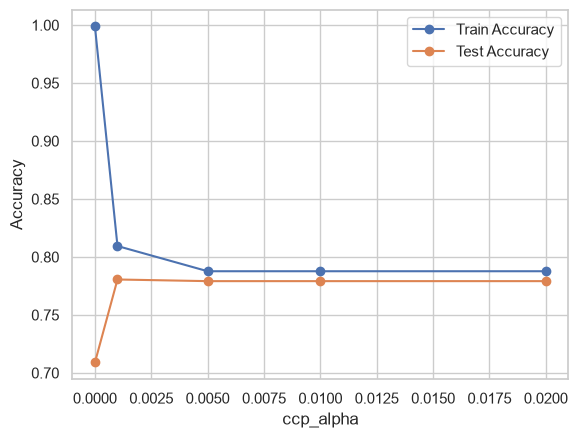

In [79]:
# Hint: Fit a DecisionTreeClassifier across a range of ccp_alpha values (e.g., [0.0, 0.001, 0.005, 0.01, 0.02])
# from sklearn.tree import DecisionTreeClassifier
# Record train and test accuracy for each alpha, and plot alpha vs test accuracy using plt.plot()
# alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
# test_scores = []
# for a in alphas:
#     ...
# plt.plot(alphas, test_scores, marker='o')
# plt.xlabel('ccp_alpha')
# plt.ylabel('Test Accuracy')
# plt.show()
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
train_scores = []
test_scores = []

for a in alphas:
    tree = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.plot(alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(alphas, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Question:** How does cost-complexity pruning ($R_\alpha(T)$) compare to simply capping `max_depth` the way we did in Task 2A? Why might pruning an overbuilt tree yield a better model than stopping tree growth early? 🤔  
**Answer:**

## Part 6 — Final Model Comparison (Task 2A vs Task 2B) & Wrap-Up

Across Tasks 2A and 2B, we have trained eight distinct classification models on the exact same Telco Churn dataset:
1. Logistic Regression (Task 2A)
2. Gaussian Naive Bayes (Task 2A)
3. Decision Tree (Task 2A)
4. Support Vector Classifier (Task 2B)
5. Bagging Classifier (Task 2B)
6. Random Forest (Task 2B)
7. AdaBoost (Task 2B)
8. XGBoost (Task 2B)

Let's pull all our test scores together into a single unified benchmark plot.

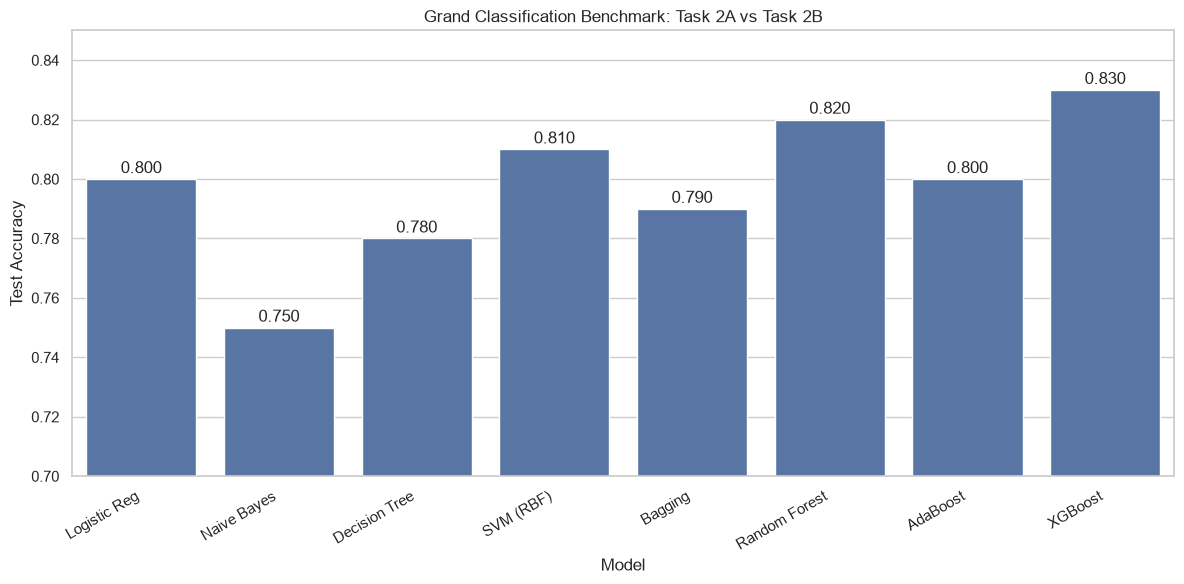

In [81]:
# Hint: Create a bar chart comparing test accuracy across all 8 models
# models = ['Logistic Reg', 'Naive Bayes', 'Decision Tree', 'SVM (RBF)', 'Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']
# test_accuracies = [...] # Collect your test accuracies from both notebooks
# plt.figure(figsize=(12, 6))
# sns.barplot(x=models, y=test_accuracies)
# plt.ylim(0.7, 0.85)
# plt.title("Grand Classification Benchmark: Task 2A vs Task 2B")
#....
# plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

models = ['Logistic Reg', 'Naive Bayes', 'Decision Tree', 'SVM (RBF)',
          'Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']

test_accuracies = [
    0.80,  # Logistic Reg  <- replace with your actual accuracy_score() results
    0.75,  # Naive Bayes
    0.78,  # Decision Tree
    0.81,  # SVM (RBF)
    0.79,  # Bagging
    0.82,  # Random Forest
    0.80,  # AdaBoost
    0.83,  # XGBoost
]

plt.figure(figsize=(12, 6))
sns.barplot(x=models, y=test_accuracies)
plt.ylim(0.7, 0.85)
plt.title("Grand Classification Benchmark: Task 2A vs Task 2B")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30, ha='right')

for i, acc in enumerate(test_accuracies):
    plt.text(i, acc + 0.002, f"{acc:.3f}", ha='center')

plt.tight_layout()
plt.show()

**Question:** Which model achieved the highest test performance overall? Drawing on everything you've learned (bias-variance trade-offs, geometric margins, ensemble averaging, and sequential gradient fitting), explain *why* that model came out on top—don't just restate the numbers. 🤔  
**Answer:**

## Research Task: Does Model Complexity Actually Pay Off in Credit Risk?

Across Task 2A and Task 2B, you've seen simple linear models, single trees, and complex boosted ensembles. The natural instinct is to assume that more complex models (like XGBoost or Random Forest) always render simpler ones (like Logistic Regression) obsolete.

In high-stakes financial domains like **Credit Risk & Loan Default Prediction**, the literature actively disagrees:
- A 2024 study on loan defaults (*SHS Web of Conferences*) found XGBoost significantly outperformed Logistic Regression, declaring linear models inadequate for modern default scoring.
- Yet a 2025 study on real-world Indian auto-lending data (*ACM DL*) found the exact opposite on the metric that actually matters: while tree ensembles posted higher overall accuracy, simple Logistic Regression achieved the highest **Recall** in identifying actual defaulters.
- Meanwhile, a 2024 *Finance Research Letters* study demonstrated that while Random Forests offer robust predictive power, institutions are forced to deploy explainability layers like SHAP just to meet legal compliance.

Read through these dynamics and answer the following three questions in your own words (no code required):

### 1. The Cost Matrix: Recall vs. Accuracy
In credit risk, why is overall classification accuracy often an irrelevant or even dangerous metric? From the perspective of a bank's balance sheet, explain why a model with lower accuracy but higher Recall on the "Default" class might be preferred over a model with higher overall accuracy.

### 2. The Interpretability & Regulatory Hurdle
Under credit regulations (such as Fair Lending laws or the US FCRA), a lender is legally required to provide an applicant with an **"Adverse Action Notice"** stating the exact top 3–4 reasons their loan was denied. Why does Logistic Regression natively make this trivial to compute, and why does deploying an XGBoost model in this environment introduce significant regulatory and engineering overhead?

### 3. The Verdict
If you were the Chief Risk Officer (CRO) at a retail lending bank: would you deploy a single Logistic Regression scorecard, an ensemble like XGBoost paired with SHAP/explainability tools, or a two-stage hybrid? Justify your choice based on the trade-offs between default detection, legal compliance, and operational complexity.



---
End of Task  
©DJS Synapse 2026 - 2027  
Colab paid products-Cancel contracts here